# 노민우, 권민재, 강지수, 이민형

In [ ]:
import torch

torch.set_num_threads(1)

import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

num_classes = 10
# 예시 분류 문제의 클래스 수를 10개로 설정

resnet50_random = resnet50(weights=None)
#  사전학습 가중치를 사용하지 않음

in_features = resnet50_random.fc.in_features
# ResNet50의 마지막 완전연결층(fc)이 입력으로 받는 feature 개수를 확인한다.

resnet50_random.fc = nn.Linear(in_features, num_classes)
# ImageNet 기준 1000개 클래스 출력층을 현재 문제의 클래스 수에 맞게 교체한다
# 최종 출력 shape은 (batch_size, num_classes)가 된다

print(resnet50_random.fc)
# Linear(in_features=2048, out_features=10, bias=True)

LOAD_PRETRAINED_MODEL = False

if LOAD_PRETRAINED_MODEL:
  weights = ResNet50_Weights.DEFAULT
  resnet50_pretrained = resnet50(weights = weights)
  resnet50_pretrained.fc = nn.Linear(resnet50_pretrained.fc.in_features, num_classes) # 출력층을 현재 클래스 수에 맞게 교체
  preprocess = weights.transforms()
  print("사전학습 ResNet-50을 불러왔습니다.")
else:
  resnet50_pretrained=None
  preprocessing=None
  print("사전학습 가중치 다운로드는 실행하지 않았습니다")


Linear(in_features=2048, out_features=10, bias=True)
사전학습 가중치 다운로드는 실행하지 않았습니다


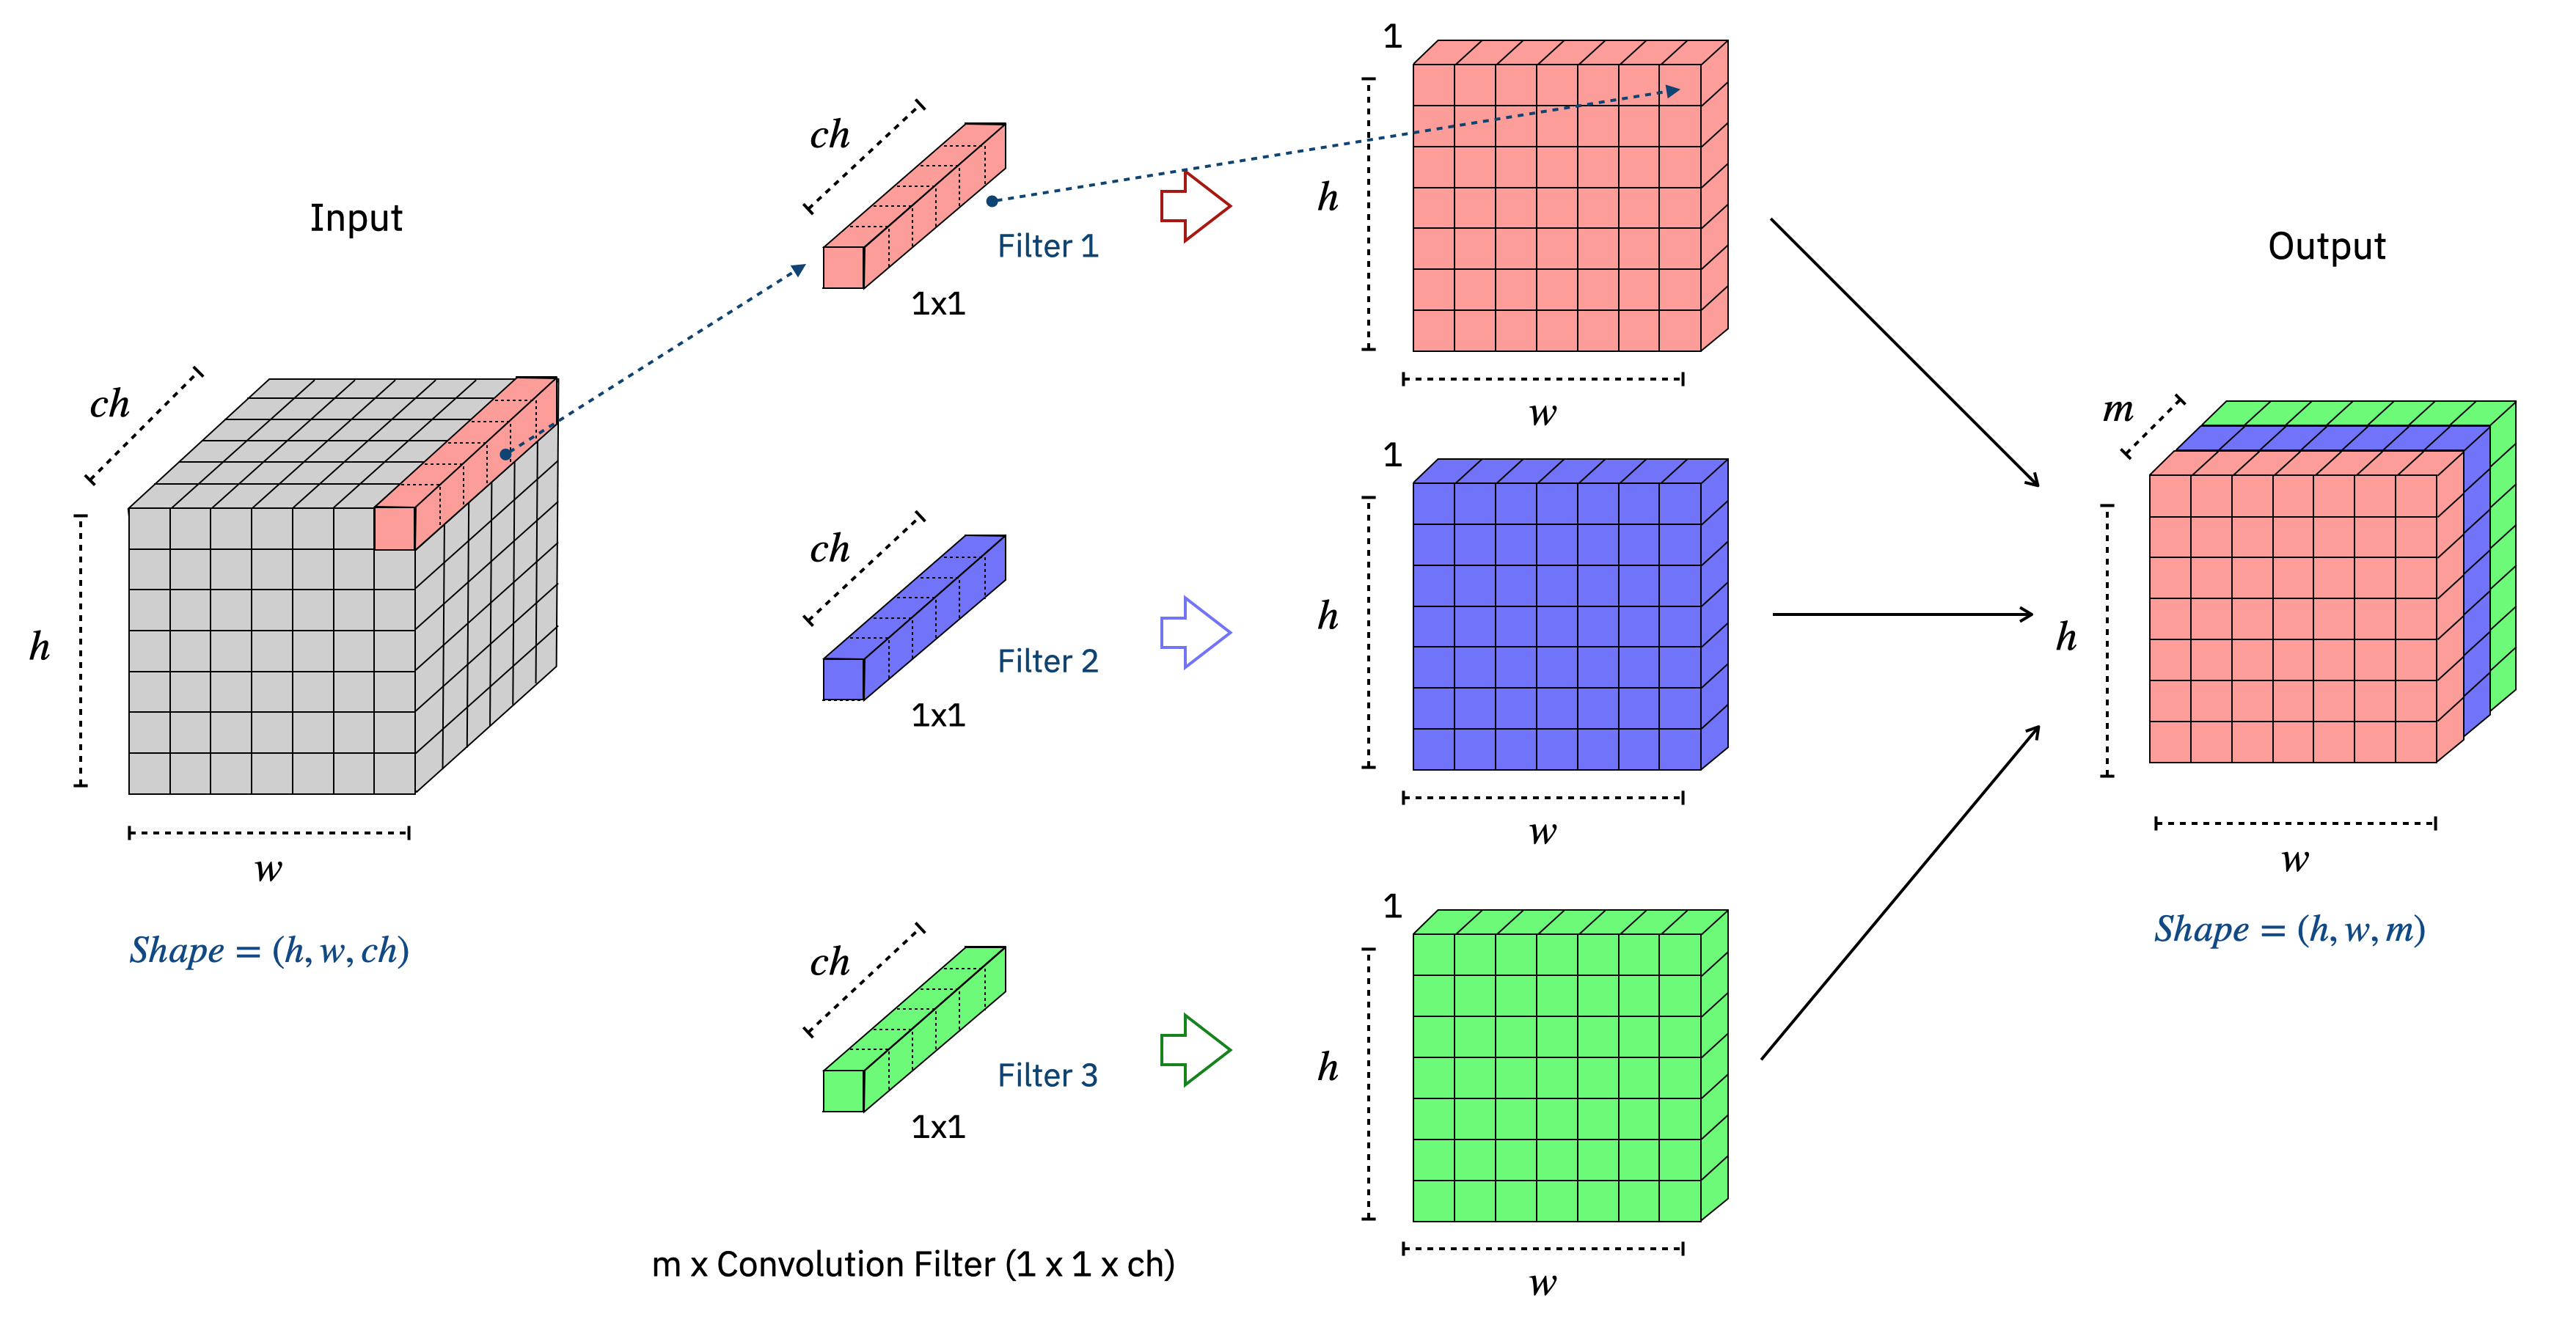

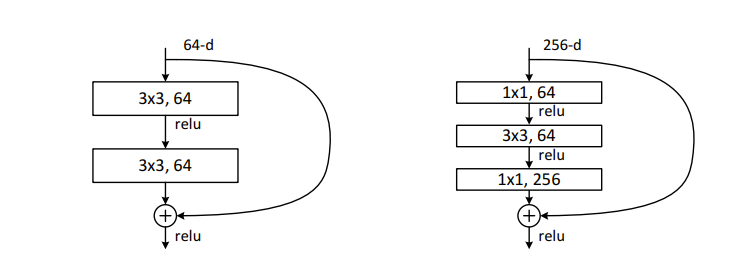

In [ ]:
class Bottleneck(nn.Module):
  expansion = 4

  def __init__(self, in_channels, out_channels, stride=1, downsample=None):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False) # 채널 수만 바꾼다

    self.bn1 = nn.BatchNorm2d(out_channels)

    self.conv2 = nn.Conv2d( # 3x3 합성곱 레이어를 정의한다.
      out_channels,
      out_channels,
      kernel_size=3,
      stride=stride,
      padding=1,
      bias=False,
    )

    self.bn2 = nn.BatchNorm2d(out_channels)  # 3X3 합성곱 결과를 채널별로 정규화

    self.conv3 = nn.Conv2d( # Bottleneck 블록의 마지막 합성곱을 정의한다.
      out_channels,
      out_channels * self.expansion,
      kernel_size=1,
      bias=False,
    )

    self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

    self.relu = nn.ReLU(inplace=True)

    self.downsample = downsample

  def forward(self, x):

    identity = x

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)
    out = self.conv3(out)
    out = self.bn3(out)

    if self.downsample is not None:
      identity = self.downsample(x)
    out += identity
    out = self.relu(out)
    return out

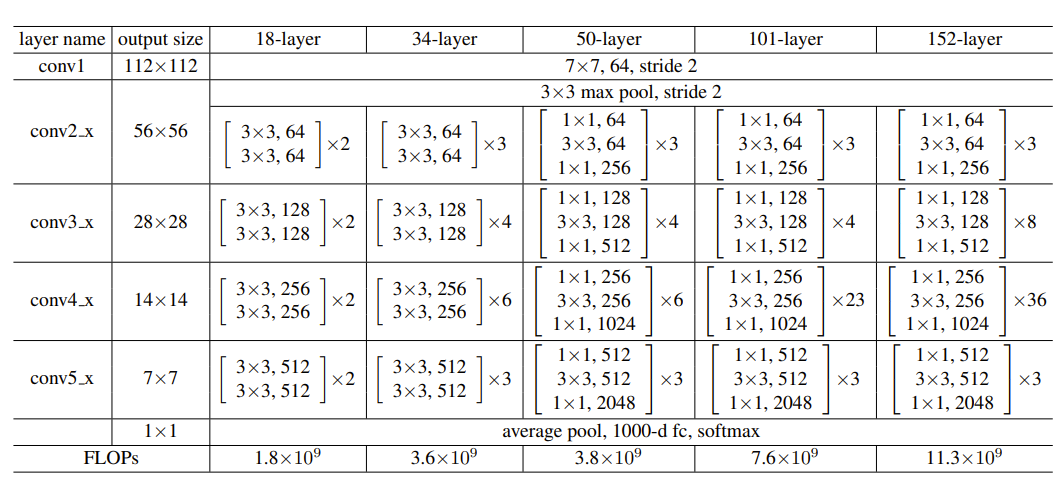

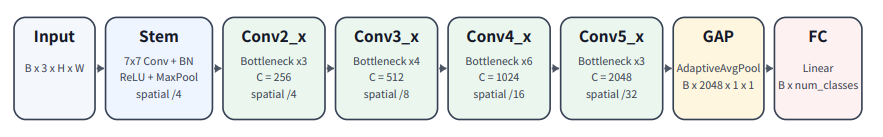

In [ ]:
class MyResNet50(nn.Module):

    def __init__(self, num_classes=1000):
        super().__init__()
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1,
        )
        self.inplanes = 64
        self.layer1 = self._make_layer(Bottleneck, 64, 3, stride=1)
        self.layer2 = self._make_layer(Bottleneck, 128, 4, stride=2)
        self.layer3 = self._make_layer(Bottleneck, 256, 6, stride=2)
        self.layer4 = self._make_layer(Bottleneck, 512, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.inplanes,
                    out_channels * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        layers = []
        layers.append(block(self.inplanes, out_channels, stride, downsample))
        self.inplanes = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x